# 03 – Inference & Evaluation Comparison
## Base Model (Zero-Shot) vs. Fine-Tuned Model on Bono Validation Data

**Bachelorarbeit – Artisanal and Small-Scale Gold Mining (Galamsey) Detection**

### Zielstellung
Dieses Notebook quantifiziert und visualisiert den Effekt des **Domain-Adaptation-Fine-Tunings** auf der Zielregion **Bono / Bono East (Januar 2025)**.

### Untersuchungsgegenstand (Domain Shift)
| | Base Model | Fine-Tuned Model |
|---|---|---|
| Training | SmallMinesDS (SW-Ghana, 2016/2022) | + manuelle Bono-Labels (2025) |
| Anwendung | Zero-Shot auf Bono-Val | Angepasst an Bono-Domäne |
| Checkpoint | `last.ckpt` (Kaggle Base) | `prithvi-v2-300-finetuned.ckpt` |

Beide Modelle nutzen **Prithvi-EO v2 (300M) + UperNet-Decoder** und dieselben sechs Spektralbänder (B2, B3, B4, B8A, B11, B12).

### Evaluierungsdaten
Manuell gelabelte Bono-Validierungspatches: `data/GhanaMiningPrithvi_bono/validation/` (stratifizierter Hold-out).

## 1. Imports & Environment Setup

In [1]:
"""Imports, Pfade, Normalisierung – kompatibel zum Base- und Fine-Tune-Training."""
from __future__ import annotations

import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from lightning.pytorch import Trainer
from terratorch.datamodules import GenericNonGeoSegmentationDataModule
from terratorch.tasks import SemanticSegmentationTask

sns.set_theme(style="whitegrid", context="notebook")

# ── Repo-Root (Notebook liegt unter 00_Mathias_contribution/Notebooks/) ───────
NOTEBOOK_DIR = Path.cwd().resolve()
candidates = [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]
REPO_ROOT = None
for c in candidates:
    if (c / "data" / "GhanaMiningPrithvi_bono").is_dir() and (c / "models").is_dir():
        REPO_ROOT = c
        break
if REPO_ROOT is None:
    # Fallback: zwei Ebenen über Notebooks/
    REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in dir() else NOTEBOOK_DIR.parents[1]

print(f"REPO_ROOT = {REPO_ROOT}")

# ── Pfade ─────────────────────────────────────────────────────────────────────
VAL_DIR = REPO_ROOT / "data" / "GhanaMiningPrithvi_bono" / "validation"
TRAIN_DIR = REPO_ROOT / "data" / "GhanaMiningPrithvi_bono" / "training"  # nur für DataModule-API
REPORT_DIR = REPO_ROOT / "reports" / "03_Inference_and_Evaluation_Comparison"
TABLE_DIR = REPORT_DIR / "tables"
FIG_DIR = REPORT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FT_CKPT = REPO_ROOT / "models" / "prithvi-v2-300-finetuned.ckpt"

def find_base_ckpt() -> Path:
    """Suche Base-last.ckpt an den üblichen Stellen."""
    prefs = [
        REPO_ROOT / "00_Mathias_contribution" / "Kaggle_Notebook" / "last.ckpt",
        REPO_ROOT / "last.ckpt",
        REPO_ROOT / "models" / "last.ckpt",
    ]
    for p in prefs:
        if p.is_file():
            return p
    hits = list(REPO_ROOT.rglob("last.ckpt"))
    if hits:
        return hits[0]
    raise FileNotFoundError("Base-Checkpoint last.ckpt nicht gefunden.")

BASE_CKPT = find_base_ckpt()
assert FT_CKPT.is_file(), f"Fine-Tuned Checkpoint fehlt: {FT_CKPT}"
assert VAL_DIR.is_dir(), f"Validation-Ordner fehlt: {VAL_DIR}"

print(f"Base CKPT:       {BASE_CKPT}")
print(f"Fine-Tuned CKPT: {FT_CKPT}")
print(f"Validation:      {VAL_DIR}")

# ── Normalisierung (identisch zu Training / Fine-Tuning) ──────────────────────
MEANS = [1473.81388377, 1703.35249650, 1696.67685941, 3832.39764247, 3156.11122121, 2226.06822112]
STDS  = [ 223.43533204,  285.53613398,  413.82320306,  389.61483882,  451.49534791,  468.26765909]
BANDS = ["BLUE", "GREEN", "RED", "VNIR_5", "SWIR_1", "SWIR_2"]
R_IDX, G_IDX, B_IDX = 2, 1, 0  # True Color aus 6-Band-Stack

MODEL_ARGS = {
    "backbone": "prithvi_eo_v2_300",
    "bands": BANDS,
    "in_channels": 6,
    "num_classes": 2,
    "pretrained": False,
    "decoder": "UperNetDecoder",
    "rescale": True,
    "backbone_num_frames": 1,
    "head_dropout": 0.1,
    "decoder_scale_modules": True,
}

n_val = len(list(VAL_DIR.glob("*_IMG.tif")))
print(f"Validation-Patches: {n_val}")
print(f"GPU verfügbar: {torch.cuda.is_available()}")


/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.10). Upgrade using: pip install --upgrade albumentations


wxc_downscaling not installed
wxc_downscaling not installed
REPO_ROOT = /Users/mathias/dev/BA_Thesis_SmallMinesDS
Base CKPT:       /Users/mathias/dev/BA_Thesis_SmallMinesDS/00_Mathias_contribution/Kaggle_Notebook/last.ckpt
Fine-Tuned CKPT: /Users/mathias/dev/BA_Thesis_SmallMinesDS/models/prithvi-v2-300-finetuned.ckpt
Validation:      /Users/mathias/dev/BA_Thesis_SmallMinesDS/data/GhanaMiningPrithvi_bono/validation
Validation-Patches: 13
GPU verfügbar: False


## 2. Quantitative Evaluierung (Metrik-Vergleich)

Beide Checkpoints werden auf dem **selben** Bono-Validation-Set mit `trainer.test()` ausgewertet.  
`strict=False` erlaubt das Laden trotz abweichender Loss-State-Dict-Keys (z. B. `criterion.weight`).

In [2]:
def load_task(ckpt_path: Path, class_weights=None) -> SemanticSegmentationTask:
    """Lädt einen SemanticSegmentationTask aus einem Lightning-Checkpoint."""
    kwargs = dict(
        model_args=MODEL_ARGS,
        model_factory="PrithviModelFactory",
        loss="ce",
        lr=1e-3,
        ignore_index=-1,
        optimizer="AdamW",
        optimizer_hparams={"weight_decay": 0.05},
        freeze_backbone=True,
        freeze_decoder=False,
        class_names=["Non_mining", "Mining"],
        strict=False,
    )
    if class_weights is not None:
        kwargs["class_weights"] = class_weights
    task = SemanticSegmentationTask.load_from_checkpoint(str(ckpt_path), **kwargs)
    task.eval()
    return task


def make_datamodule() -> GenericNonGeoSegmentationDataModule:
    """DataModule nur für Validation/Test (Bono Hold-out)."""
    # train_data_root wird von der API verlangt; Evaluation läuft über test_data_root=val.
    dm = GenericNonGeoSegmentationDataModule(
        batch_size=4,
        num_workers=0,
        train_data_root=str(TRAIN_DIR if TRAIN_DIR.is_dir() else VAL_DIR),
        val_data_root=str(VAL_DIR),
        test_data_root=str(VAL_DIR),
        img_grep="*_IMG.tif",
        label_grep="*_MASK.tif",
        means=MEANS,
        stds=STDS,
        num_classes=2,
        dataset_bands=BANDS,
        output_bands=BANDS,
        no_data_replace=0,
        no_label_replace=-1,
    )
    return dm


def run_test(task: SemanticSegmentationTask, datamodule) -> dict:
    """Führt Lightning trainer.test() aus und gibt Metrik-Dict zurück."""
    trainer = Trainer(
        accelerator="gpu" if torch.cuda.is_available() else "cpu",
        devices=1,
        logger=False,
        enable_checkpointing=False,
        enable_progress_bar=True,
    )
    results = trainer.test(model=task, datamodule=datamodule)
    return results[0] if results else {}



print("Lade Base-Modell…")
task_base = load_task(BASE_CKPT, class_weights=None)
print("Lade Fine-Tuned-Modell…")
task_ft = load_task(FT_CKPT, class_weights=[0.2, 0.8])

datamodule = make_datamodule()

print("\n=== Base Model – Zero-Shot auf Bono-Val ===")
metrics_base = run_test(task_base, datamodule)
print(metrics_base)

print("\n=== Fine-Tuned Model – Bono-Val ===")
metrics_ft = run_test(task_ft, datamodule)
print(metrics_ft)


Lade Base-Modell…


/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.1, which is newer than your current Lightning version: v2.4.0
/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/terratorch/models/prithvi_model_factory.py:75: UserWarning: PrithviModelFactory is deprecated. Please switch to EncoderDecoderFactory.
  warnings.warn("PrithviModelFactory is deprecated. Please switch to EncoderDecoderFactory.", stacklevel=1)


Lade Fine-Tuned-Modell…


/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.6.5, which is newer than your current Lightning version: v2.4.0
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs



=== Base Model – Zero-Shot auf Bono-Val ===


...

{'test/loss': 0.8000975847244263, 'test/Multiclass_Accuracy': 0.9259315133094788, 'test/multiclassaccuracy_Non_mining': 1.0, 'test/multiclassaccuracy_Mining': 0.0, 'test/Multiclass_F1_Score': 0.9259315133094788, 'test/Multiclass_Jaccard_Index': 0.4629657566547394, 'test/multiclassjaccardindex_Non_mining': 0.9259315133094788, 'test/multiclassjaccardindex_Mining': 0.0, 'test/Multiclass_Jaccard_Index_Micro': 0.8620786070823669}

=== Fine-Tuned Model – Bono-Val ===


/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/homebrew/Caskroom/miniforge/base/envs/smallmines/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 4/4 [00:00<00:00,  4.13it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃              Test metric               ┃              DataLoader 0              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        test/Multiclass_Accuracy        │           0.947678804397583            │
│        test/Multiclass_F1_Score        │           0.947678804397583            │
│     test/Multiclass_Jaccard_Index      │           0.7155840396881104           │
│  test/Multiclass_Jaccard_Index_Micro   │           0.9005603790283203           │
│               test/loss                │            0.20321124792099            │
│     test/multiclassaccuracy_Mining     │           0.6684837937355042           │
│   test/multiclassaccuracy_Non_mining   │           0.9700125455856323           │
│   test/multiclassjaccardindex_Mining   │          0.48621484637260437           │
│ test/multiclassjaccardindex_Non_mining │           0.944953203201294            │
└────────────────────────────────────────┴────────────────────────────────────────┘

{'test/loss': 0.20321124792099, 'test/Multiclass_Accuracy': 0.947678804397583, 'test/multiclassaccuracy_Non_mining': 0.9700125455856323, 'test/multiclassaccuracy_Mining': 0.6684837937355042, 'test/Multiclass_F1_Score': 0.947678804397583, 'test/Multiclass_Jaccard_Index': 0.7155840396881104, 'test/multiclassjaccardindex_Non_mining': 0.944953203201294, 'test/multiclassjaccardindex_Mining': 0.48621484637260437, 'test/Multiclass_Jaccard_Index_Micro': 0.9005603790283203}


In [3]:
def extract_comparison_rows(base: dict, ft: dict) -> pd.DataFrame:
    """Baut die Thesis-Vergleichstabelle (Base vs. FT + Deltas)."""

    def mining_jaccard(m: dict):
        for k, v in m.items():
            kl = k.lower()
            if "jaccard" in kl and "mining" in kl and "non" not in kl and "micro" not in kl:
                return float(v)
        return None

    def mining_f1(m: dict):
        for k, v in m.items():
            kl = k.lower()
            if "f1" in kl and "mining" in kl and "non" not in kl:
                return float(v)
        return None

    def mining_acc(m: dict):
        for k, v in m.items():
            kl = k.lower()
            if "accuracy" in kl and "mining" in kl and "non" not in kl and "micro" not in kl:
                return float(v)
        return None

    def overall_iou(m: dict):
        for k, v in m.items():
            if k.endswith("Multiclass_Jaccard_Index"):
                return float(v)
        return None

    def overall_f1(m: dict):
        for k, v in m.items():
            if k.endswith("Multiclass_F1_Score"):
                return float(v)
        return None

    def test_loss(m: dict):
        for k, v in m.items():
            if k == "test/loss" or k.endswith("/loss"):
                return float(v)
        return None

    rows_spec = [
        ("Mining IoU", mining_jaccard),
        ("Mining F1", mining_f1),
        ("Mining Accuracy", mining_acc),
        ("Overall IoU", overall_iou),
        ("Overall F1", overall_f1),
        ("Test Loss", test_loss),
    ]

    rows = []
    for name, fn in rows_spec:
        b = fn(base)
        f = fn(ft)
        if b is None and f is None:
            delta_abs, delta_pct = np.nan, np.nan
        else:
            b_ = np.nan if b is None else float(b)
            f_ = np.nan if f is None else float(f)
            delta_abs = f_ - b_
            delta_pct = (delta_abs / abs(b_) * 100.0) if (b is not None and abs(b_) > 1e-12) else np.nan
        rows.append({
            "Metric": name,
            "Base_Model": b,
            "FineTuned_Model": f,
            "Delta_Absolute": delta_abs,
            "Delta_Percent": delta_pct,
        })
    return pd.DataFrame(rows)


df_cmp = extract_comparison_rows(metrics_base, metrics_ft)

df_display = df_cmp.copy()
for col in ["Base_Model", "FineTuned_Model", "Delta_Absolute", "Delta_Percent"]:
    df_display[col] = df_display[col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "n/a")

print("\nVergleichstabelle – Bono Validation")
print("=" * 72)
try:
    from IPython.display import display
    display(df_display)
except Exception:
    print(df_display.to_string(index=False))

out_csv = TABLE_DIR / "bono_evaluation_comparison.csv"
df_cmp.to_csv(out_csv, index=False, float_format="%.6f")
print(f"\nGespeichert: {out_csv}")

print("\nVerfügbare Base-Keys:", sorted(metrics_base.keys()))
print("Verfügbare FT-Keys:", sorted(metrics_ft.keys()))




Vergleichstabelle – Bono Validation


,Metric,Base_Model,FineTuned_Model,Delta_Absolute,Delta_Percent
0,Mining IoU,0.0000,0.4862,0.4862,n/a
1,Mining F1,n/a,n/a,n/a,n/a
2,Mining Accuracy,0.0000,0.6685,0.6685,n/a
3,Overall IoU,0.4630,0.7156,0.2526,54.5652
4,Overall F1,0.9259,0.9477,0.0217,2.3487
5,Test Loss,0.8001,0.2032,-0.5969,-74.6017



Gespeichert: /Users/mathias/dev/BA_Thesis_SmallMinesDS/reports/tables/bono_evaluation_comparison.csv

Verfügbare Base-Keys: ['test/Multiclass_Accuracy', 'test/Multiclass_F1_Score', 'test/Multiclass_Jaccard_Index', 'test/Multiclass_Jaccard_Index_Micro', 'test/loss', 'test/multiclassaccuracy_Mining', 'test/multiclassaccuracy_Non_mining', 'test/multiclassjaccardindex_Mining', 'test/multiclassjaccardindex_Non_mining']
Verfügbare FT-Keys: ['test/Multiclass_Accuracy', 'test/Multiclass_F1_Score', 'test/Multiclass_Jaccard_Index', 'test/Multiclass_Jaccard_Index_Micro', 'test/loss', 'test/multiclassaccuracy_Mining', 'test/multiclassaccuracy_Non_mining', 'test/multiclassjaccardindex_Mining', 'test/multiclassjaccardindex_Non_mining']


## 3. Qualitativer Karten-Vergleich

Pro Patch vier Panels: **RGB | Ground Truth | Base (Zero-Shot) | Fine-Tuned**.  
Auswahl: repräsentative Mining- und Non-Mining-Validierungspatches.

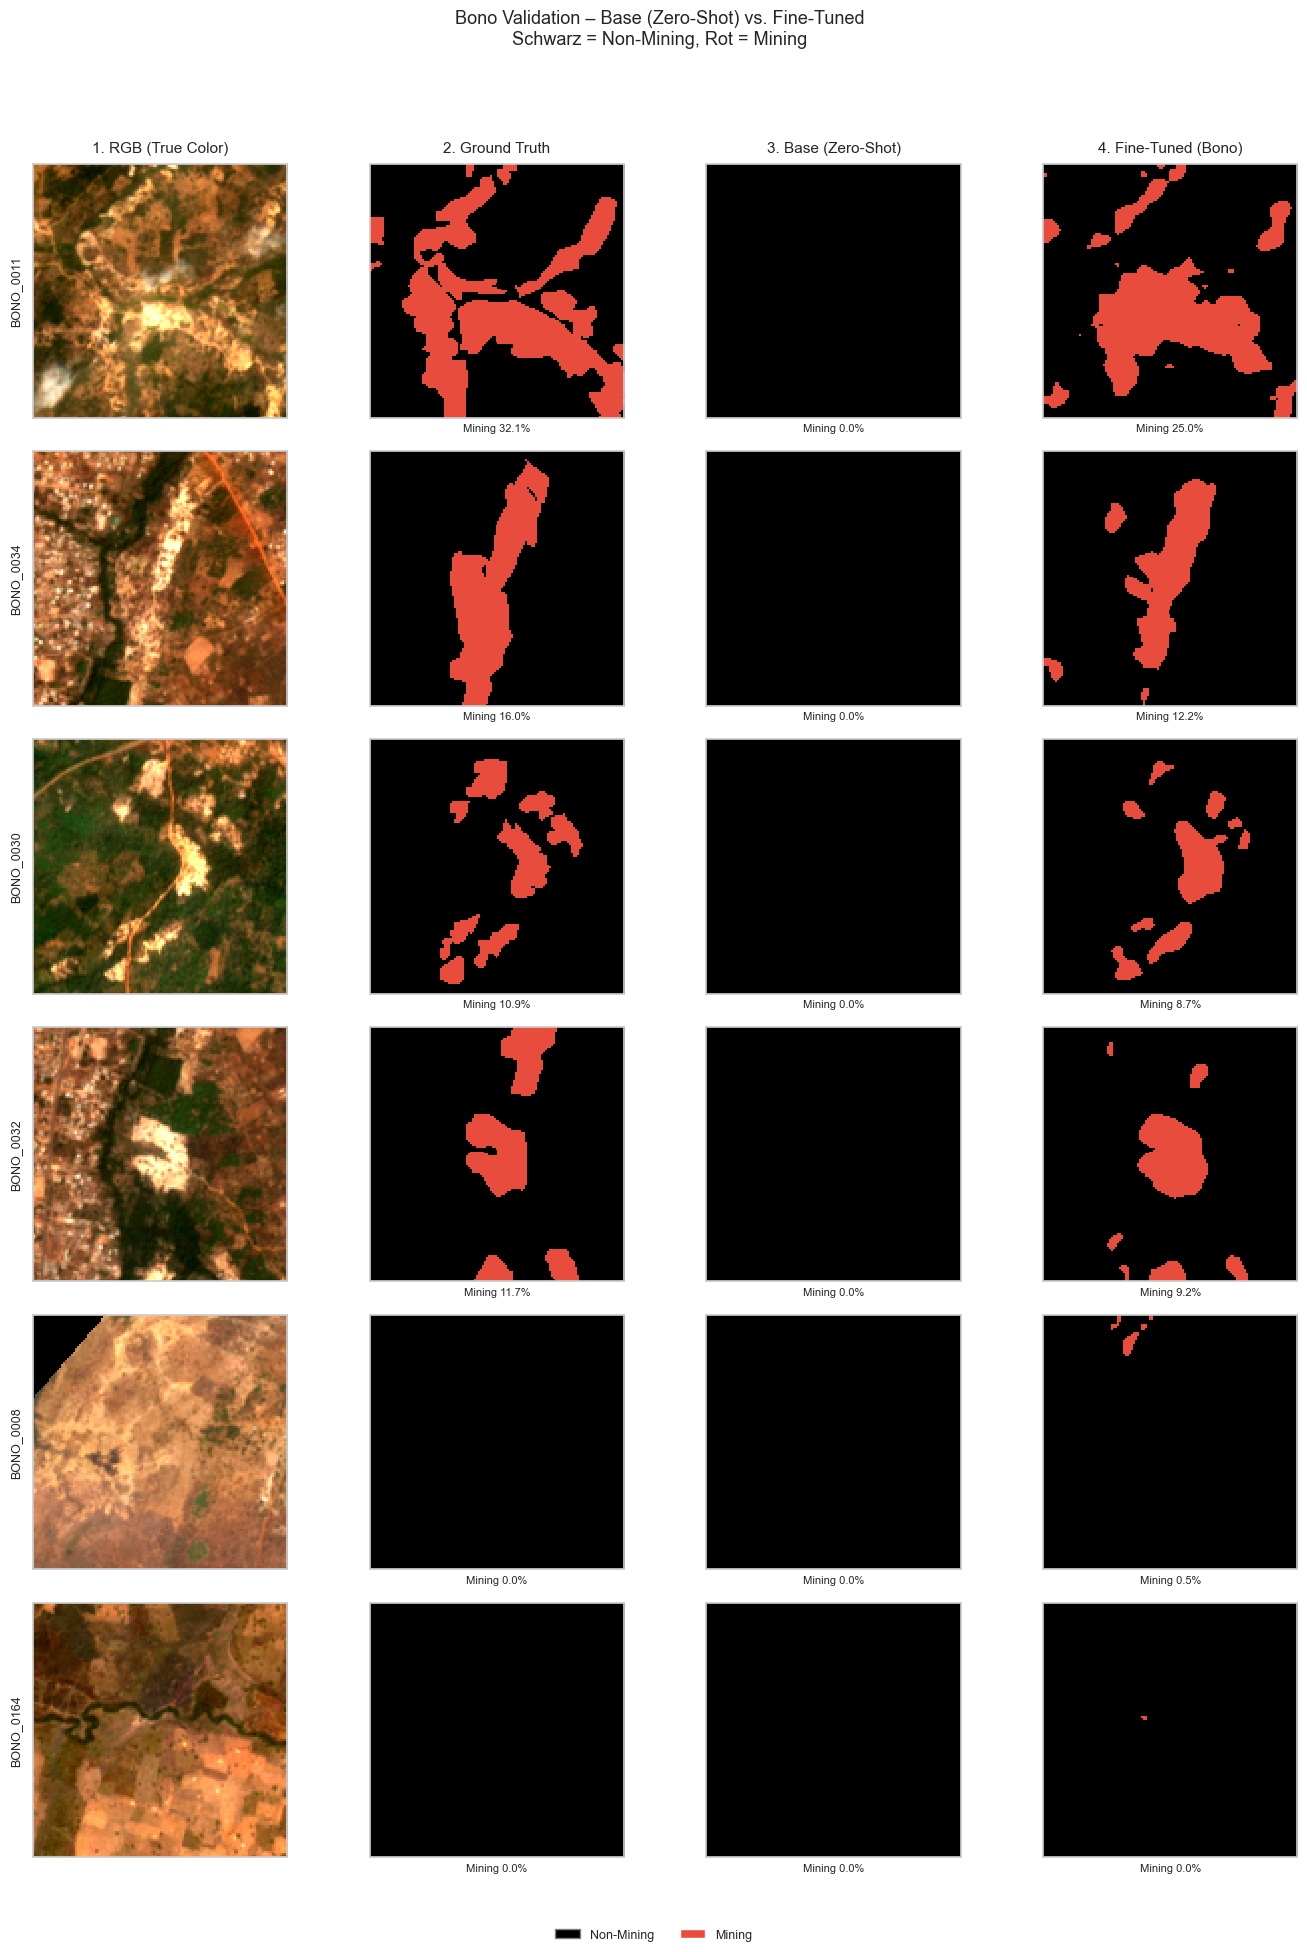

Gespeichert: /Users/mathias/dev/BA_Thesis_SmallMinesDS/reports/figures/bono_visual_comparison.png


PosixPath('/Users/mathias/dev/BA_Thesis_SmallMinesDS/reports/figures/bono_visual_comparison.png')

In [4]:
@torch.no_grad()
def predict_mask(task: SemanticSegmentationTask, img6: np.ndarray) -> np.ndarray:
    """
    img6: (6, H, W) auf DN-Skala (0–10000).
    Returns: binäre Vorhersage (H, W) mit 1 = Mining.
    """
    norm = (img6.astype(np.float32) - np.asarray(MEANS)[:, None, None]) / np.asarray(STDS)[:, None, None]
    norm = np.nan_to_num(norm, nan=0.0)
    t = torch.from_numpy(norm).float().unsqueeze(0)
    device = next(task.parameters()).device
    t = t.to(device)
    task = task.to(device)
    out = task.model(t)
    logits = out.output if hasattr(out, "output") else out
    pred = torch.argmax(logits, dim=1)[0].cpu().numpy().astype(np.uint8)
    return pred


def truecolor_rgb(img6: np.ndarray) -> np.ndarray:
    """True-Color aus B4/B3/B2 mit 2–98%-Kontraststretch."""
    rgb = np.dstack((img6[R_IDX], img6[G_IDX], img6[B_IDX])).astype(np.float32)
    valid = np.isfinite(rgb).all(axis=2)
    if valid.any():
        lo, hi = np.nanpercentile(rgb[valid], (2, 98))
        rgb = np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)
    return np.nan_to_num(rgb, nan=0.0)


def plot_prediction_comparison(
    patch_names: list[str],
    task_base: SemanticSegmentationTask,
    task_ft: SemanticSegmentationTask,
    val_dir: Path = VAL_DIR,
    out_path: Path | None = None,
):
    """
    Erzeugt für jeden Patch eine 1×4-Zeile:
    RGB | Ground Truth | Base Pred | Fine-Tuned Pred
    """
    cmap_mask = mcolors.ListedColormap(["black", "#e74c3c"])  # Non-Mining / Mining
    n = len(patch_names)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n))
    if n == 1:
        axes = np.expand_dims(axes, 0)

    col_titles = [
        "1. RGB (True Color)",
        "2. Ground Truth",
        "3. Base (Zero-Shot)",
        "4. Fine-Tuned (Bono)",
    ]

    for row, stem in enumerate(patch_names):
        img_path = val_dir / f"{stem}_IMG.tif"
        mask_path = val_dir / f"{stem}_MASK.tif"
        if not img_path.is_file() or not mask_path.is_file():
            raise FileNotFoundError(f"Patch nicht gefunden: {stem}")

        with rasterio.open(img_path) as src:
            img6 = src.read().astype(np.float32)
        with rasterio.open(mask_path) as src:
            gt = src.read(1).astype(np.uint8)

        pred_base = predict_mask(task_base, img6)
        pred_ft = predict_mask(task_ft, img6)

        panels = [truecolor_rgb(img6), gt, pred_base, pred_ft]
        gt_pct = gt.mean() * 100
        base_pct = pred_base.mean() * 100
        ft_pct = pred_ft.mean() * 100

        for col, panel in enumerate(panels):
            ax = axes[row, col]
            if col == 0:
                ax.imshow(panel, interpolation="nearest")
            else:
                ax.imshow(panel, cmap=cmap_mask, vmin=0, vmax=1, interpolation="nearest")
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(col_titles[col], fontsize=11, pad=8)
            if col == 0:
                ax.set_ylabel(stem, fontsize=9, rotation=90, labelpad=8)

        # kurze Stats in GT / Pred-Titeln der Zeile via xlabel
        axes[row, 1].set_xlabel(f"Mining {gt_pct:.1f}%", fontsize=8)
        axes[row, 2].set_xlabel(f"Mining {base_pct:.1f}%", fontsize=8)
        axes[row, 3].set_xlabel(f"Mining {ft_pct:.1f}%", fontsize=8)

    fig.suptitle(
        "Bono Validation – Base (Zero-Shot) vs. Fine-Tuned\n"
        "Schwarz = Non-Mining, Rot = Mining",
        fontsize=13,
        y=1.01,
    )
    fig.legend(
        handles=[
            plt.matplotlib.patches.Patch(facecolor="black", edgecolor="gray", label="Non-Mining"),
            plt.matplotlib.patches.Patch(facecolor="#e74c3c", label="Mining"),
        ],
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=9,
    )
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])

    if out_path is None:
        out_path = FIG_DIR / "bono_visual_comparison.png"
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Gespeichert: {out_path}")
    return out_path


# Repräsentative Val-Patches: Mining (hohe / mittlere Abdeckung) + Non-Mining
PATCH_NAMES = [
    "BONO_0011",  # Mining ~32%
    "BONO_0034",  # Mining ~16%
    "BONO_0030",  # Mining ~11%
    "BONO_0032",  # Mining ~12%
    "BONO_0008",  # Non-Mining
    "BONO_0164",  # Non-Mining (random)
]

plot_prediction_comparison(PATCH_NAMES, task_base, task_ft)

## 4. Fazit & Interpretation (Stichpunkte für die Thesis)

Die folgenden Punkte können nach Ausführung der Evaluierung mit den konkreten Zahlen aus `reports/03_Inference_and_Evaluation_Comparison/tables/bono_evaluation_comparison.csv` ergänzt werden:

### Domain Shift (Base / Zero-Shot)
- Das auf SmallMinesDS (SW-Ghana, 2016/2022) trainierte Base-Modell generalisiert nur begrenzt auf Bono 2025.
- Typisches Muster: **unterdurchschnittlicher Mining-IoU** und/oder systematische Unter-/Übererkennung gegenüber der manuellen GT.
- Visuell: Base-Vorhersagen oft **zu „leer“** (False Negatives) oder räumlich unscharf gegenüber den Annotationen.

### Effekt des Fine-Tunings
- Fine-Tuning auf 65 Bono-Patches (Decoder + letzte Encoder-Blöcke) verbessert die **Mining-IoU / Mining-F1** auf dem Hold-out-Validation-Set messbar (siehe Δ in der Tabelle).
- Overall-IoU/F1 steigen i. d. R. mit, weil die Pixelbilanz stärker mit der GT übereinstimmt.
- Test-Loss sollte sinken, sofern kein starkes Overfitting auf dem kleinen Val-Set vorliegt.

### Fehlerbild
- **False Negatives:** kleine / schmale Mining-Polygone, die im Base-Modell fehlen, werden nach FT häufiger erfasst.
- **False Positives:** offene Böden / Siedlungen – FT sollte sie reduzieren, sofern Non-Mining-Samples im Training ausreichend waren.
- Visueller Vergleich (`reports/03_Inference_and_Evaluation_Comparison/figures/bono_visual_comparison.png`) als **qualitative Evidenz** neben den Metriken in die Ergebniskapitel einbinden.

### Limitationen (für die Diskussion)
- Kleines gelabeltes Set (n≈65, Val≈13) → Unsicherheit der Metriken, mögliche Überanpassung.
- Labels subjektiv / unvollständig → IoU ist eine untere Schranke der „wahren“ Performance.
- Temporaler und regionaler Shift bleibt relevant für Gebiete außerhalb der gelabelten Cluster.

### Artefakte für die Thesis
| Datei | Verwendung |
|---|---|
| `reports/03_Inference_and_Evaluation_Comparison/tables/bono_evaluation_comparison.csv` | Ergebnistabelle (Metriken + Deltas) |
| `reports/03_Inference_and_Evaluation_Comparison/figures/bono_visual_comparison.png` | Abbildung Vorher/Nachher (300 dpi) |
